In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

## The Dataset
https://docs.google.com/spreadsheets/d/1eXzleAqDSH4G9QyKOYPjOUYb8Fl4RG_k/edit?gid=1235822571#gid=1235822571

In [ ]:
df = pd.read_csv('FinancialMarketData.csv', skiprows=4)  # Skipping metadata rows
df

,Unnamed: 0,Unnamed: 1,Index Currency,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 50,Unnamed: 51,Unnamed: 52,Unnamed: 53,Unnamed: 54,Unnamed: 55,Unnamed: 56,Unnamed: 57,Unnamed: 58,Unnamed: 59
0,NaN,NaN,Ticker,XAU BGNL Curncy,ECSURPUS Index,BDIY Index,CRY Index,DXY Curncy,JPY Curncy,GBP Curncy,...,TY1 Comdty,GC1 Comdty,CO1 Comdty,ES1 Index,VG1 Index,NQ1 Index,LLL1 Index,TP1 Index,DU1 Comdty,TU2 Comdty
1,NaN,NaN,NaN,284.250,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,4/27/1999,282.250,NaN,995.000,134.650,100.630,120.440,1.617,...,115.563,282.300,15.800,1376.500,3726.000,NaN,NaN,1347.500,105.690,104.898
3,Depth,ED-22AY,5/4/1999,285.550,NaN,1095.000,139.040,100.680,120.770,1.626,...,114.313,286.900,16.930,1343.000,3740.000,NaN,NaN,1328.500,105.580,104.664
4,Date,PX_Last,5/11/1999,278.250,NaN,1121.000,136.780,100.240,121.070,1.621,...,113.344,278.800,15.960,1358.250,3690.000,NaN,NaN,1343.500,105.670,104.406
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1145,NaN,NaN,3/23/2021,1727.960,0.339,2271.000,184.502,92.336,108.720,1.376,...,131.922,1725.100,60.790,3899.800,3773.000,13006.250,1103.600,1958.500,112.140,110.383
1146,NaN,NaN,3/30/2021,1685.560,0.303,2103.000,184.874,93.297,110.290,1.372,...,131.188,1683.900,64.140,3947.700,3872.000,12878.250,1103.600,1978.000,112.090,110.387
1147,NaN,NaN,4/6/2021,1743.280,0.440,2092.000,185.839,92.335,109.880,1.382,...,131.688,1741.500,62.740,4064.000,3920.000,13570.000,1103.600,1955.000,112.120,110.281
1148,NaN,NaN,4/13/2021,1742.690,0.467,2140.000,188.137,91.852,109.190,1.374,...,132.078,1746.200,63.670,4132.800,3917.000,13975.750,1103.600,1961.500,112.115,110.293


In [ ]:
df.describe()

,Unnamed: 0,Unnamed: 1,Index Currency,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 50,Unnamed: 51,Unnamed: 52,Unnamed: 53,Unnamed: 54,Unnamed: 55,Unnamed: 56,Unnamed: 57,Unnamed: 58,Unnamed: 59
count,8,8,1149,1150,1112,1149,1149,1149,1149,1149,...,1149,1149,1149,1149,1149,1141,706,1149,1149,1149
unique,8,8,1149,1127,748,960,1132,1111,996,559,...,906,1090,1088,1051,887,1085,191,891,779,705
top,Depth,ED-22AY,Ticker,318.550,-0.174,1090.000,194.180,100.230,109.460,1.570,...,125.828,272.300,72.460,1192.250,3455.000,1570.000,1103.600,1642.000,112.050,99.648
freq,1,1,1,3,5,4,2,3,5,8,...,4,3,3,3,5,4,514,5,6,60


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1150 entries, 0 to 1149
Data columns (total 60 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Unnamed: 0      8 non-null      object
 1   Unnamed: 1      8 non-null      object
 2   Index Currency  1149 non-null   object
 3   Unnamed: 3      1150 non-null   object
 4   Unnamed: 4      1112 non-null   object
 5   Unnamed: 5      1149 non-null   object
 6   Unnamed: 6      1149 non-null   object
 7   Unnamed: 7      1149 non-null   object
 8   Unnamed: 8      1149 non-null   object
 9   Unnamed: 9      1149 non-null   object
 10  Unnamed: 10     1149 non-null   object
 11  Unnamed: 11     1149 non-null   object
 12  Unnamed: 12     1149 non-null   object
 13  Unnamed: 13     1149 non-null   object
 14  Unnamed: 14     1149 non-null   object
 15  Unnamed: 15     1149 non-null   object
 16  Unnamed: 16     1149 non-null   object
 17  Unnamed: 17     1149 non-null   object
 18  Unnamed:

In [ ]:
df.columns = df.iloc[0]
df = df[1:]  # Remove the first row used as headers
df.reset_index(drop=True, inplace=True)

In [ ]:
# df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
df.head()

,NaN,NaN,Ticker,XAU BGNL Curncy,ECSURPUS Index,BDIY Index,CRY Index,DXY Curncy,JPY Curncy,GBP Curncy,...,TY1 Comdty,GC1 Comdty,CO1 Comdty,ES1 Index,VG1 Index,NQ1 Index,LLL1 Index,TP1 Index,DU1 Comdty,TU2 Comdty
0,NaN,NaN,NaN,284.250,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,4/27/1999,282.250,NaN,995.000,134.650,100.630,120.440,1.617,...,115.563,282.300,15.800,1376.500,3726.000,NaN,NaN,1347.500,105.690,104.898
2,Depth,ED-22AY,5/4/1999,285.550,NaN,1095.000,139.040,100.680,120.770,1.626,...,114.313,286.900,16.930,1343.000,3740.000,NaN,NaN,1328.500,105.580,104.664
3,Date,PX_Last,5/11/1999,278.250,NaN,1121.000,136.780,100.240,121.070,1.621,...,113.344,278.800,15.960,1358.250,3690.000,NaN,NaN,1343.500,105.670,104.406
4,Days (T/W/A),W,5/18/1999,273.950,NaN,1061.000,133.900,100.720,123.210,1.621,...,112.344,274.200,15.140,1341.250,3595.000,NaN,NaN,1323.500,105.600,104.141


### Drop colums with Nan as header

In [ ]:
df = df.loc[:, ~df.columns.isnull()]  # Drop columns with NaN as header
df.head()

,Ticker,XAU BGNL Curncy,ECSURPUS Index,BDIY Index,CRY Index,DXY Curncy,JPY Curncy,GBP Curncy,Cl1 Comdty,VIX Index,...,TY1 Comdty,GC1 Comdty,CO1 Comdty,ES1 Index,VG1 Index,NQ1 Index,LLL1 Index,TP1 Index,DU1 Comdty,TU2 Comdty
0,NaN,284.250,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,4/27/1999,282.250,NaN,995.000,134.650,100.630,120.440,1.617,17.810,23.360,...,115.563,282.300,15.800,1376.500,3726.000,NaN,NaN,1347.500,105.690,104.898
2,5/4/1999,285.550,NaN,1095.000,139.040,100.680,120.770,1.626,18.920,25.620,...,114.313,286.900,16.930,1343.000,3740.000,NaN,NaN,1328.500,105.580,104.664
3,5/11/1999,278.250,NaN,1121.000,136.780,100.240,121.070,1.621,18.060,25.620,...,113.344,278.800,15.960,1358.250,3690.000,NaN,NaN,1343.500,105.670,104.406
4,5/18/1999,273.950,NaN,1061.000,133.900,100.720,123.210,1.621,17.110,27.260,...,112.344,274.200,15.140,1341.250,3595.000,NaN,NaN,1323.500,105.600,104.141


In [ ]:
# Drop columns with more than 50% missing values
df = df.dropna(axis=1, thresh=int(df.shape[0] * 0.5))

# Forward fill for time-series data
df = df.fillna(method='ffill')


In [ ]:
# Rename and convert Ticker to Date
df.rename(columns={'Ticker': 'Date'}, inplace=True)
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# Drop rows where Date is NaT (invalid dates)
df = df.dropna(subset=['Date'])

In [ ]:
# Drop rows where Date is NaN
df = df[df['Date'].notna()]

In [ ]:
df.set_index('Date', inplace=True)


In [ ]:
# Convert all columns to numeric where possible
df = df.apply(pd.to_numeric, errors='coerce')


In [ ]:
print(df.info())        # Check data types and missing values
print(df.describe())    # Summary statistics

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1148 entries, 1999-04-27 to 2021-04-20
Data columns (total 57 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   XAU BGNL Curncy  1148 non-null   float64
 1   ECSURPUS Index   1111 non-null   float64
 2   BDIY Index       1148 non-null   float64
 3   CRY Index        1148 non-null   float64
 4   DXY Curncy       1148 non-null   float64
 5   JPY Curncy       1148 non-null   float64
 6   GBP Curncy       1148 non-null   float64
 7   Cl1 Comdty       1148 non-null   float64
 8   VIX Index        1148 non-null   float64
 9   USGG30YR Index   1148 non-null   float64
 10  GT10 Govt        1148 non-null   float64
 11  USGG2YR Index    1148 non-null   float64
 12  USGG3M Index     1148 non-null   float64
 13  US0001M Index    1148 non-null   float64
 14  GTDEM30Y Govt    1148 non-null   float64
 15  GTDEM10Y Govt    1148 non-null   float64
 16  GTDEM2Y Govt     1148 non-null   float64
 

In [ ]:
df.to_csv('cleaned_financial_data.csv', index=True)

In [ ]:
df.head()

,XAU BGNL Curncy,ECSURPUS Index,BDIY Index,CRY Index,DXY Curncy,JPY Curncy,GBP Curncy,Cl1 Comdty,VIX Index,USGG30YR Index,...,TY1 Comdty,GC1 Comdty,CO1 Comdty,ES1 Index,VG1 Index,NQ1 Index,LLL1 Index,TP1 Index,DU1 Comdty,TU2 Comdty
Date,,,,,,,,,,,,,,,,,,,,,
1999-04-27,282.25,NaN,995.0,134.65,100.63,120.44,1.617,17.81,23.36,5.538,...,115.563,282.3,15.80,1376.50,3726.0,NaN,NaN,1347.5,105.69,104.898
1999-05-04,285.55,NaN,1095.0,139.04,100.68,120.77,1.626,18.92,25.62,5.713,...,114.313,286.9,16.93,1343.00,3740.0,NaN,NaN,1328.5,105.58,104.664
1999-05-11,278.25,NaN,1121.0,136.78,100.24,121.07,1.621,18.06,25.62,5.835,...,113.344,278.8,15.96,1358.25,3690.0,NaN,NaN,1343.5,105.67,104.406
1999-05-18,273.95,NaN,1061.0,133.90,100.72,123.21,1.621,17.11,27.26,5.890,...,112.344,274.2,15.14,1341.25,3595.0,NaN,NaN,1323.5,105.60,104.141
1999-05-25,271.45,NaN,1017.0,132.09,101.38,122.85,1.602,17.14,28.90,5.748,...,113.125,270.8,15.43,1284.50,3631.0,NaN,NaN,1307.0,105.68,104.289


In [ ]:
# df.rename(columns={'PX_Last': 'Price_Last', 'XAU BGNL Curncy': 'Gold'}, inplace=True)

## Plots

### Gold Prices

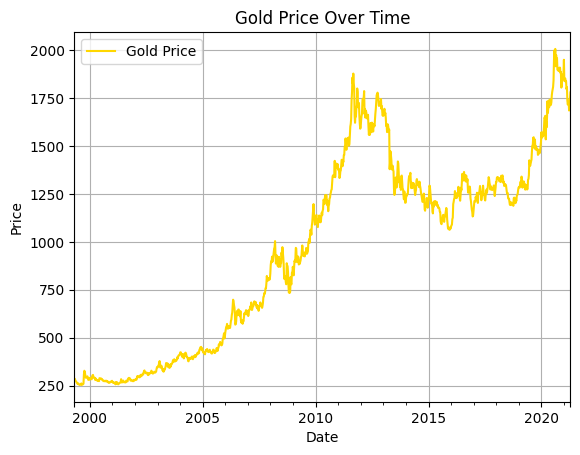

In [ ]:
df['XAU BGNL Curncy'].plot(label='Gold Price', color='gold')
plt.title('Gold Price Over Time')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid()
plt.show()

### VIX Index Over Time

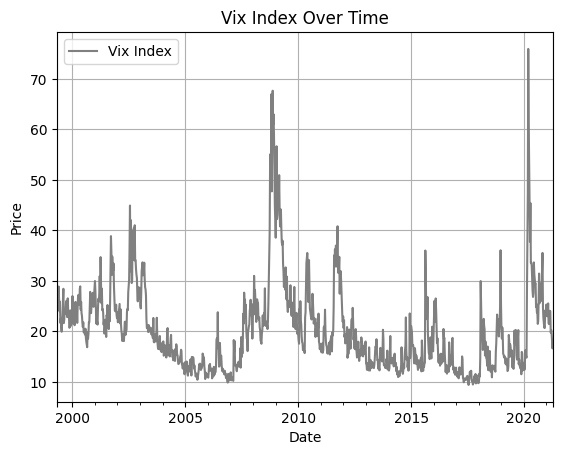

In [ ]:
df['VIX Index'].plot(label='Vix Index', color='grey')
plt.title('Vix Index Over Time')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid()
plt.show()

###  Correlation Heatmap

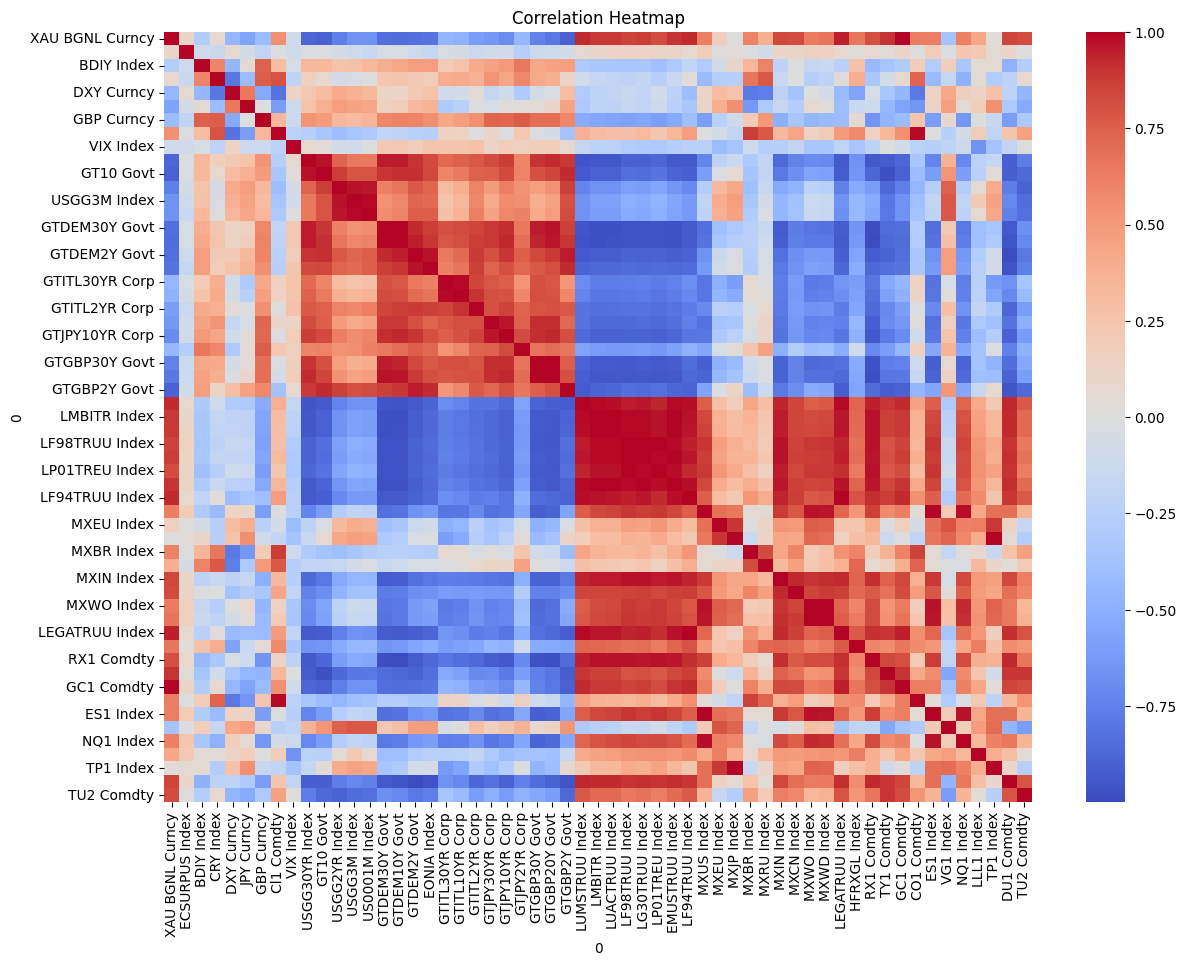

In [ ]:
import seaborn as sns
import numpy as np

# Calculate correlation matrix
corr_matrix = df.corr()

# Plot heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0, cbar=True)
plt.title('Correlation Heatmap')
plt.show()

### Histogram for Distribution

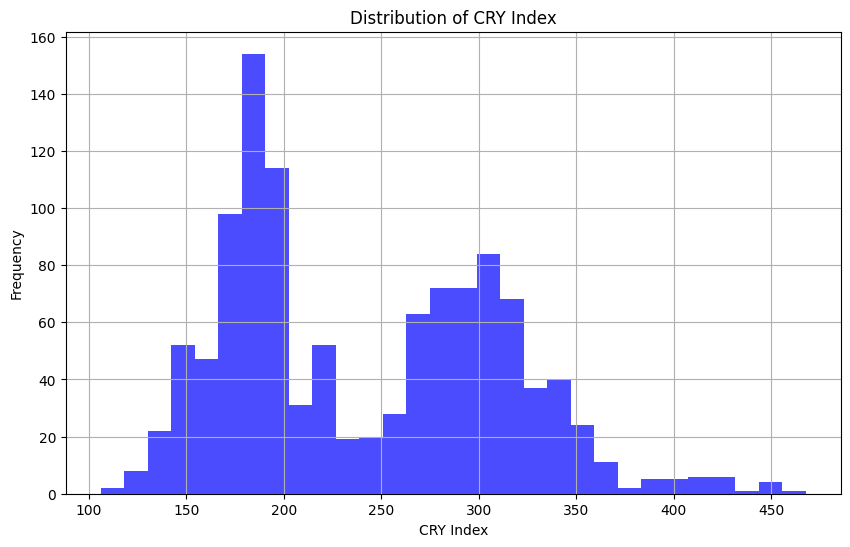

In [ ]:
df['CRY Index'].plot(kind='hist', bins=30, color='blue', alpha=0.7, figsize=(10, 6))
plt.title('Distribution of CRY Index')
plt.xlabel('CRY Index')
plt.ylabel('Frequency')
plt.grid()
plt.show()

### Pair Plot

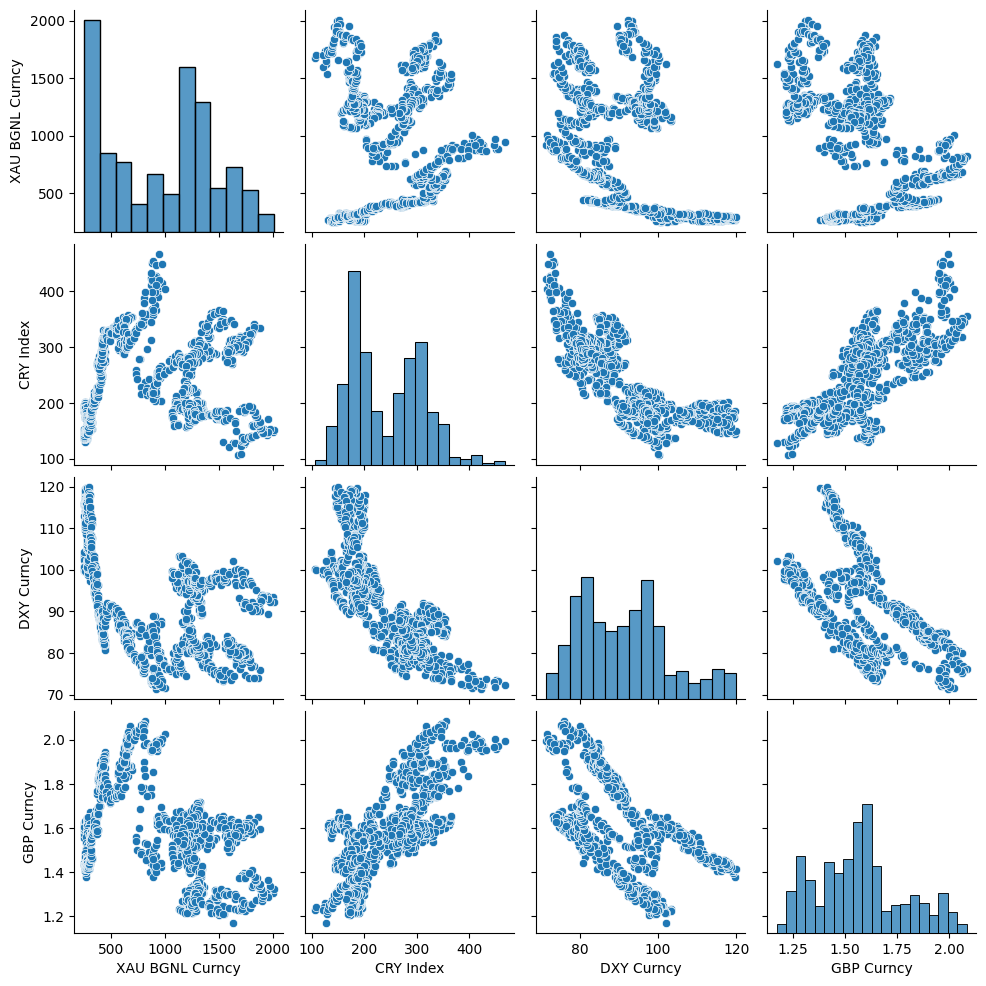

In [ ]:
selected_columns = ['XAU BGNL Curncy', 'CRY Index', 'DXY Curncy', 'GBP Curncy']
sns.pairplot(df[selected_columns])
plt.show()

### 30-Day Moving Average of Gold Prices

### 30-Day Moving Average of Gold Prices

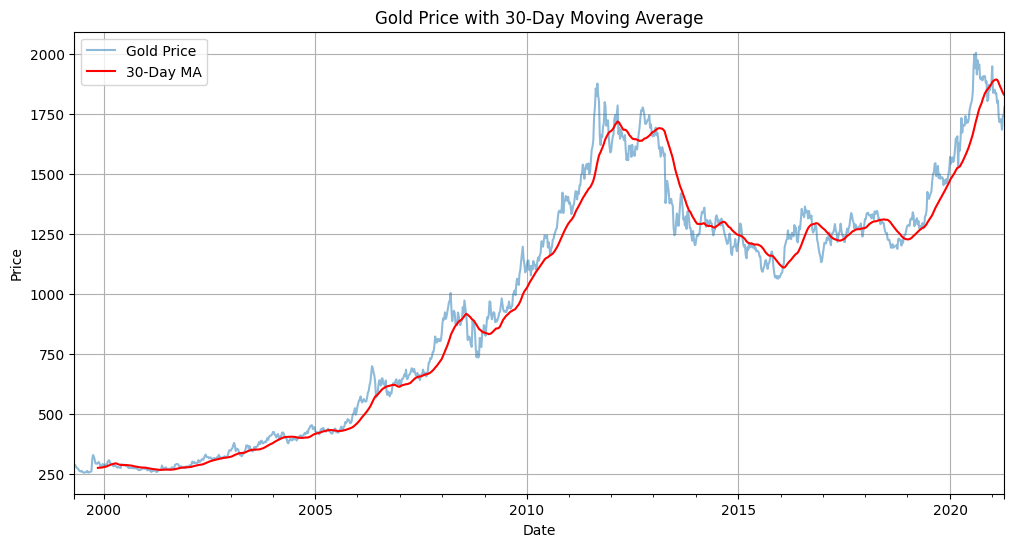

In [ ]:
df['XAU BGNL Curncy_MA30'] = df['XAU BGNL Curncy'].rolling(window=30).mean()

plt.figure(figsize=(12, 6))
df['XAU BGNL Curncy'].plot(label='Gold Price', alpha=0.5)
df['XAU BGNL Curncy_MA30'].plot(label='30-Day MA', color='red')
plt.title('Gold Price with 30-Day Moving Average')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid()
plt.show()

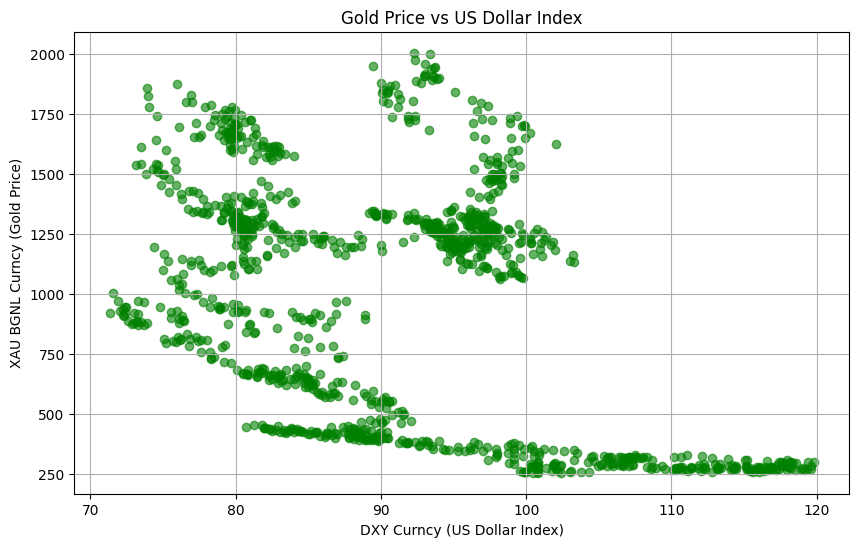

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(df['DXY Curncy'], df['XAU BGNL Curncy'], alpha=0.6, color='green')
plt.title('Gold Price vs US Dollar Index')
plt.xlabel('DXY Curncy (US Dollar Index)')
plt.ylabel('XAU BGNL Curncy (Gold Price)')
plt.grid()
plt.show()

### Missing Data Heatmap

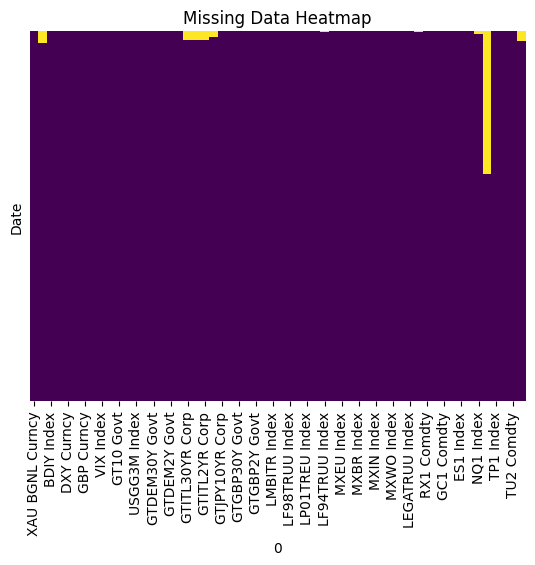

In [ ]:
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Missing Data Heatmap')
plt.show()

## Advanced Visualisation


In [ ]:
df.head()

,XAU BGNL Curncy,ECSURPUS Index,BDIY Index,CRY Index,DXY Curncy,JPY Curncy,GBP Curncy,Cl1 Comdty,VIX Index,USGG30YR Index,...,GC1 Comdty,CO1 Comdty,ES1 Index,VG1 Index,NQ1 Index,LLL1 Index,TP1 Index,DU1 Comdty,TU2 Comdty,XAU BGNL Curncy_MA30
Date,,,,,,,,,,,,,,,,,,,,,
1999-04-27,282.25,NaN,995.0,134.65,100.63,120.44,1.617,17.81,23.36,5.538,...,282.3,15.80,1376.50,3726.0,NaN,NaN,1347.5,105.69,104.898,NaN
1999-05-04,285.55,NaN,1095.0,139.04,100.68,120.77,1.626,18.92,25.62,5.713,...,286.9,16.93,1343.00,3740.0,NaN,NaN,1328.5,105.58,104.664,NaN
1999-05-11,278.25,NaN,1121.0,136.78,100.24,121.07,1.621,18.06,25.62,5.835,...,278.8,15.96,1358.25,3690.0,NaN,NaN,1343.5,105.67,104.406,NaN
1999-05-18,273.95,NaN,1061.0,133.90,100.72,123.21,1.621,17.11,27.26,5.890,...,274.2,15.14,1341.25,3595.0,NaN,NaN,1323.5,105.60,104.141,NaN
1999-05-25,271.45,NaN,1017.0,132.09,101.38,122.85,1.602,17.14,28.90,5.748,...,270.8,15.43,1284.50,3631.0,NaN,NaN,1307.0,105.68,104.289,NaN


### Rename Columns

In [ ]:
# Define the mapping of current column names to new names
rename_mapping = {
    'XAU BGNL Curncy': 'Gold',
    'ECSURPUS Index': 'EuroSurplus',
    'BDIY Index': 'BalticDry',
    'CRY Index': 'CommodityIndex',
    'DXY Curncy': 'DollarIndex',
    'JPY Curncy': 'Yen',
    'GBP Curncy': 'Pound',
    'Cl1 Comdty': 'CrudeOil',
    'VIX Index': 'VIX',
    'USGG30YR Index': 'US30YrYield',
    'GC1 Comdty': 'GoldFuture',
    'CO1 Comdty': 'CrudeOilFuture',
    'ES1 Index': 'S&P500Future',
    'VG1 Index': 'EuroStoxxFuture',
    'NQ1 Index': 'NasdaqFuture',
    'LLL1 Index': 'LongBondFuture',
    'TP1 Index': 'TIPSFuture',
    'DU1 Comdty': 'DutchNaturalGas',
    'TU2 Comdty': 'ShortBondFuture',
    'XAU BGNL Curncy_MA30': 'Gold_MA30',
}

# Apply the renaming
df.rename(columns=rename_mapping, inplace=True)

# Display the renamed columns
print(df.columns)


Index(['Gold', 'EuroSurplus', 'BalticDry', 'CommodityIndex', 'DollarIndex',
       'Yen', 'Pound', 'CrudeOil', 'VIX', 'US30YrYield', 'GT10 Govt',
       'USGG2YR Index', 'USGG3M Index', 'US0001M Index', 'GTDEM30Y Govt',
       'GTDEM10Y Govt', 'GTDEM2Y Govt', 'EONIA Index', 'GTITL30YR Corp',
       'GTITL10YR Corp', 'GTITL2YR Corp', 'GTJPY30YR Corp', 'GTJPY10YR Corp',
       'GTJPY2YR Corp', 'GTGBP30Y Govt', 'GTGBP20Y Govt', 'GTGBP2Y Govt',
       'LUMSTRUU Index', 'LMBITR Index', 'LUACTRUU Index', 'LF98TRUU Index',
       'LG30TRUU Index', 'LP01TREU Index', 'EMUSTRUU Index', 'LF94TRUU Index',
       'MXUS Index', 'MXEU Index', 'MXJP Index', 'MXBR Index', 'MXRU Index',
       'MXIN Index', 'MXCN Index', 'MXWO Index', 'MXWD Index',
       'LEGATRUU Index', 'HFRXGL Index', 'RX1 Comdty', 'TY1 Comdty',
       'GoldFuture', 'CrudeOilFuture', 'S&P500Future', 'EuroStoxxFuture',
       'NasdaqFuture', 'LongBondFuture', 'TIPSFuture', 'DutchNaturalGas',
       'ShortBondFuture', 'Gold_MA30'],
  

### Distribution Plot (sns.histplot):

Helps you see the distribution of values and potential outliers.
Kernel Density Estimate (kde=True) adds a smoothed curve over the histogram.


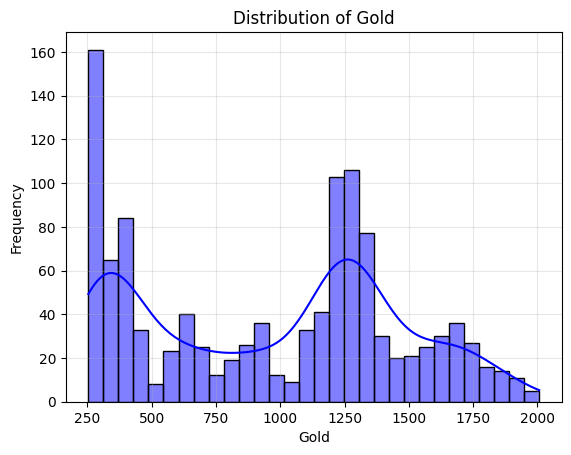

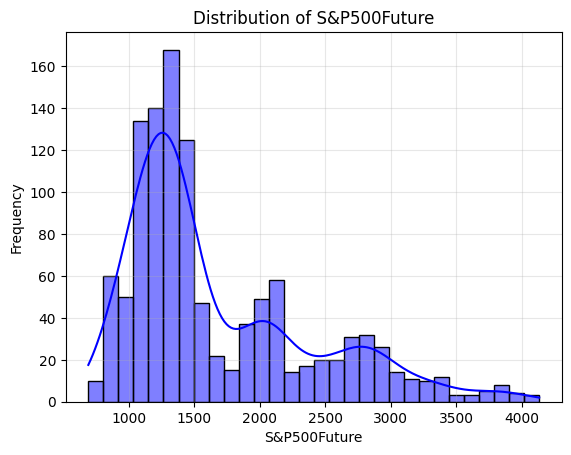

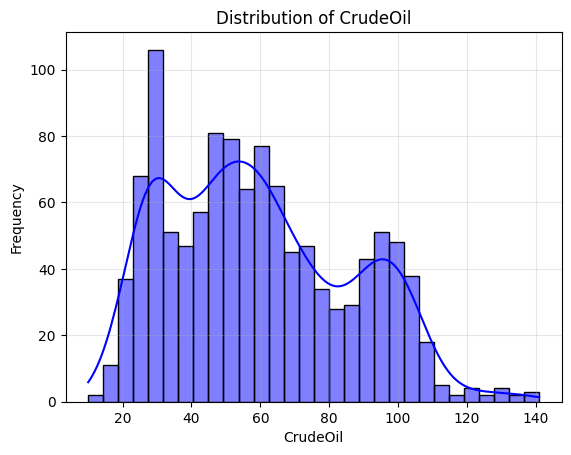

In [ ]:
# Columns for visualization
key_columns = ['Gold', 'S&P500Future', 'CrudeOil']

for col in key_columns:
    sns.histplot(df[col], kde=True, color='blue', bins=30)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.grid(True, alpha=0.3)
    plt.show()

### Rolling Mean & Standard Deviation:

Rolling Mean: Detects trends and seasonality by smoothing out short-term fluctuations.
Standard Deviation: Highlights periods of high volatility or unusual activity.

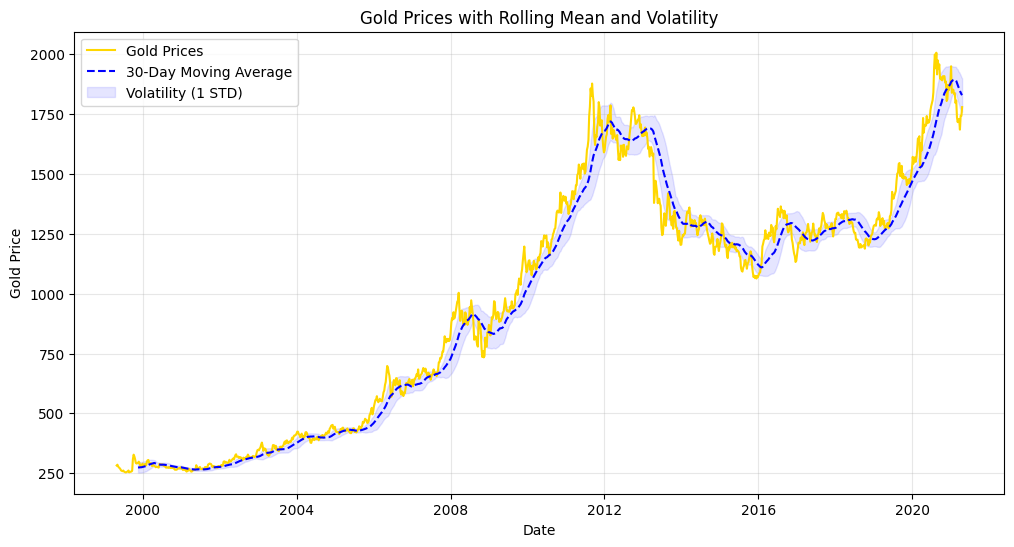

In [ ]:
# Rolling window size
window_size = 30

# Calculate rolling mean and standard deviation for Gold
df['Gold_MA'] = df['Gold'].rolling(window=window_size).mean()
df['Gold_STD'] = df['Gold'].rolling(window=window_size).std()

# Plot Gold Prices with Rolling Mean
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Gold'], label='Gold Prices', color='gold')
plt.plot(df.index, df['Gold_MA'], label='30-Day Moving Average', color='blue', linestyle='--')
plt.fill_between(df.index,
                 df['Gold_MA'] - df['Gold_STD'],
                 df['Gold_MA'] + df['Gold_STD'],
                 color='blue', alpha=0.1, label='Volatility (1 STD)')
plt.title('Gold Prices with Rolling Mean and Volatility')
plt.xlabel('Date')
plt.ylabel('Gold Price')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Clean the Data

In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# Impute missing values
imputer = SimpleImputer(strategy='mean')
df_imputed = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)

# Scale numerical features
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df_imputed)

# Create a DataFrame for scaled features
df_scaled = pd.DataFrame(scaled_features, columns=df.columns)

### Create Target

In [ ]:
# Define crash (binary target variable)
df_scaled['Crash'] = (df_scaled['S&P500Future'].pct_change() < -0.05).astype(int)

## Add Features - Rolling stats for gold and S&P Future

In [ ]:
df_scaled['Gold_RollMean'] = df_scaled['Gold'].rolling(window=30).mean()
df_scaled['S&P500_RollVol'] = df_scaled['S&P500Future'].rolling(window=30).std()

# Drop NaN values introduced by rolling
df_scaled = df_scaled.dropna()

### Split into training and testing sets

In [ ]:
from sklearn.model_selection import train_test_split

# Define features and target
X = df_scaled.drop(columns=['Crash'])
y = df_scaled['Crash']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
X_train.head()

,Gold,EuroSurplus,BalticDry,CommodityIndex,DollarIndex,Yen,Pound,CrudeOil,VIX,US30YrYield,...,NasdaqFuture,LongBondFuture,TIPSFuture,DutchNaturalGas,ShortBondFuture,Gold_MA30,Gold_MA,Gold_STD,Gold_RollMean,S&P500_RollVol
213,-1.188893,-1.120865,-0.003095,-0.476937,0.129468,0.802904,0.334472,-1.140760,-0.015216,0.334956,...,-0.876524,-2.251582e-15,-1.426478,-0.332375,0.478108,-1.280936,-1.280936,-0.910907,-1.238779,0.052705
740,0.557910,0.255651,-0.528687,0.542197,-0.680576,-0.481739,-0.258841,1.521453,-0.431099,-0.413866,...,-0.218456,3.877436e-01,-0.334971,0.682203,1.012461,1.182248,1.182248,3.134230,1.136652,0.103416
515,-0.140254,-2.456639,0.037026,-0.496252,-0.205372,-0.638001,-0.928709,-0.520777,2.840905,-0.207633,...,-0.901520,-5.431992e+00,-1.764542,0.023294,0.580111,-0.257417,-0.257417,0.646178,-0.251723,0.243345
289,-1.052234,-0.614494,1.422222,0.606684,-0.621782,-0.085981,1.377553,-0.457869,-0.762634,0.789978,...,-0.743464,-2.251582e-15,-0.557821,-0.496748,-0.334723,-1.158432,-1.158432,-1.030120,-1.120639,0.027558
427,-0.618549,0.258561,2.045108,1.074840,-0.862253,1.219863,2.138333,0.453157,-0.609168,0.949563,...,-0.571124,-2.251582e-15,1.516043,-1.542499,-1.303455,-0.634800,-0.634800,-0.807507,-0.615662,0.064930


In [ ]:
y_train.head()

,Crash
213,0
740,1
515,0
289,1
427,1


### Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
import pickle

# Train Logistic Regression model
lr_model = LogisticRegression(random_state=42)
lr_model.fit(X_train, y_train)

# Evaluate
y_pred = lr_model.predict(X_test)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.80      1.00      0.89       178
           1       1.00      0.04      0.08        46

    accuracy                           0.80       224
   macro avg       0.90      0.52      0.49       224
weighted avg       0.84      0.80      0.72       224



In [ ]:
lr_predictions = lr_model.predict(X_test)

In [ ]:
lr_predictions

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0])

### XGBoost

In [ ]:
from xgboost import XGBClassifier

# Train XGBoost model
xgb_model = XGBClassifier()
xgb_model.fit(X_train, y_train)

# Evaluate
y_pred_xgb = xgb_model.predict(X_test)
print(classification_report(y_test, y_pred_xgb))


              precision    recall  f1-score   support

           0       0.83      0.94      0.88       178
           1       0.52      0.26      0.35        46

    accuracy                           0.80       224
   macro avg       0.68      0.60      0.61       224
weighted avg       0.77      0.80      0.77       224



### Models Evaluation

AUC-ROC: 0.5995359062042013


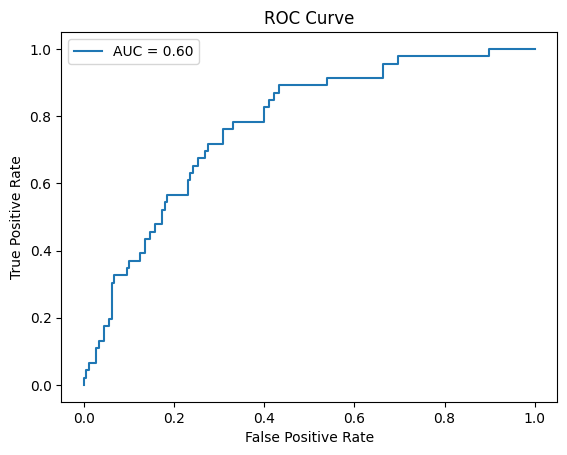

In [ ]:
from sklearn.metrics import roc_auc_score, roc_curve

# AUC-ROC
roc_auc = roc_auc_score(y_test, y_pred_xgb)
print(f"AUC-ROC: {roc_auc}")

# Plot ROC curve
fpr, tpr, _ = roc_curve(y_test, xgb_model.predict_proba(X_test)[:, 1])
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()


### Interpret Results

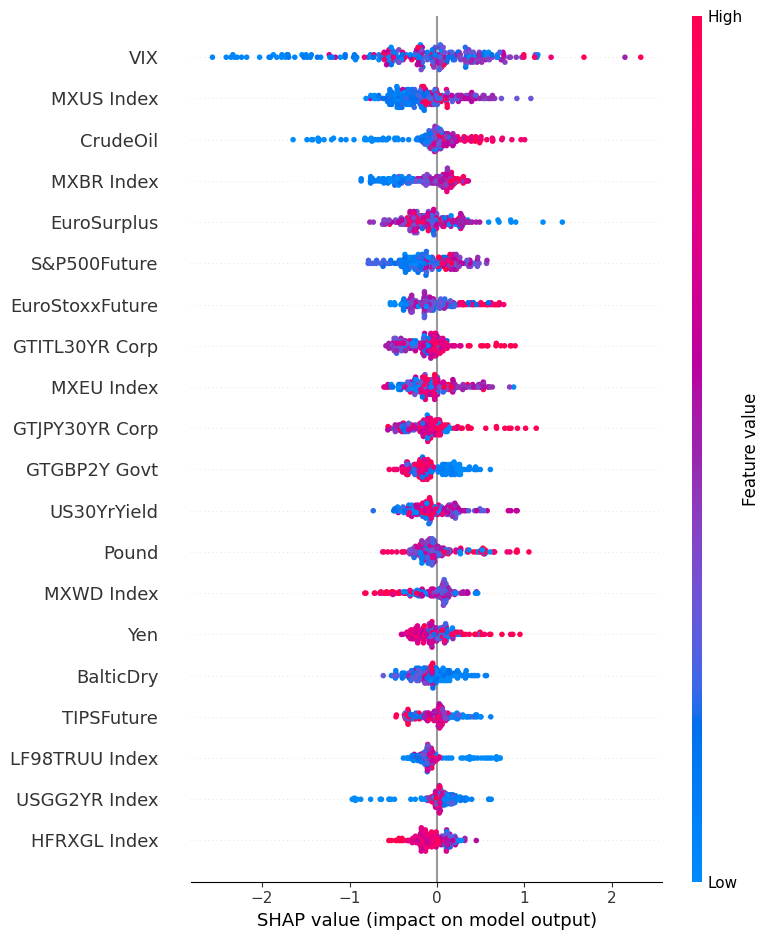

In [ ]:
import shap

# SHAP values for XGBoost
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

# Summary plot
shap.summary_plot(shap_values, X_test)

In [ ]:
# import joblib

# # Save model
# joblib.dump(xgb, 'market_crash_model_xgb.pkl')

# # Save scaler
# joblib.dump(scaler, 'scaler.pkl')

# # Save imputer
# joblib.dump(imputer, 'imputer.pkl')
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

### Save PLus Other Model

In [ ]:
def evaluate_and_save(model, X_train, y_train, X_test, y_test, filename):
  model.fit(X_train, y_train)
  y_pred = model.predict(X_test)
  accuracy = accuracy_score(y_test, y_pred)
  print(f"{model.__class__.__name__} Accuracy: {accuracy:.4f}")
  print(f"\nClassification Report:\n{classification_report(y_test, y_pred)}")
  print("------------------------------------")

  # wb opens the file in binary mode
  with open(filename, 'wb') as file:
    pickle.dump(model, file)

  print(f"Model saved to {filename}")

In [ ]:
from sys import set_coroutine_origin_tracking_depth

evaluate_and_save(xgb_model, X_train, y_train, X_test, y_test, "xgb_model.pkl")

dt_model = DecisionTreeClassifier(random_state=42)
evaluate_and_save(dt_model, X_train, y_train, X_test, y_test, "dt_model.pkl")

rf_model = RandomForestClassifier(random_state=42)
evaluate_and_save(rf_model, X_train, y_train, X_test, y_test, "rf_model.pkl")

XGBClassifier Accuracy: 0.7991

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.94      0.88       178
           1       0.52      0.26      0.35        46

    accuracy                           0.80       224
   macro avg       0.68      0.60      0.61       224
weighted avg       0.77      0.80      0.77       224

------------------------------------
Model saved to xgb_model.pkl
DecisionTreeClassifier Accuracy: 0.7143

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.82      0.82       178
           1       0.30      0.30      0.30        46

    accuracy                           0.71       224
   macro avg       0.56      0.56      0.56       224
weighted avg       0.71      0.71      0.71       224

------------------------------------
Model saved to dt_model.pkl
RandomForestClassifier Accuracy: 0.7902

Classification Report:
              precision    recal